# Mixture of Mixture of Gaussians Example

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib
import scipy
from copy import copy
from sklearn.preprocessing import KernelCenterer

#import code to generate data and do clustNP
from sample_distributions import pair_sample_mixture_of_GMs
# from NDIGO import gauss_kernal_mat, proj_simplex
from NDIGO import * #periodic_kernel_mat


import gpytorch

# Set Parameters

In [21]:
np.random.seed(123)

n = 150 # number of total paired samples
nhold = 100
ntest = 100
M = 2   # true number of mixture components for our KDE
Mprime = 1
d = 1   # ambient dimension 

#w_outer = np.random.rand(M,) # true KDE mixture proportions
w_outer = np.ones((M,))
w_outer *= 1/np.sum(w_outer)
w_inner = np.ones((M,1))
#mus = 2*np.random.randn(1, d, M) # true means for each mixture distribution
mus = np.ones((1, d, M))
#mus[0,0,0] = -2
sigmas = np.ones((1,d,d,M))


noise_sd = .1

# Generate Data

In [22]:
X, component_ids, pair_ids = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=n)
Xh, cid_h, pid_h = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=nhold)
Xte, cid_te, pid_te = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=ntest)
w_outer

X = np.random.uniform(-4*np.pi,4*np.pi,(2*n,1)) #just reuse component ids since all are coming from the same distribution

### Plot Pairs as endpoints of line segments

Text(0.5, 0, 'x')

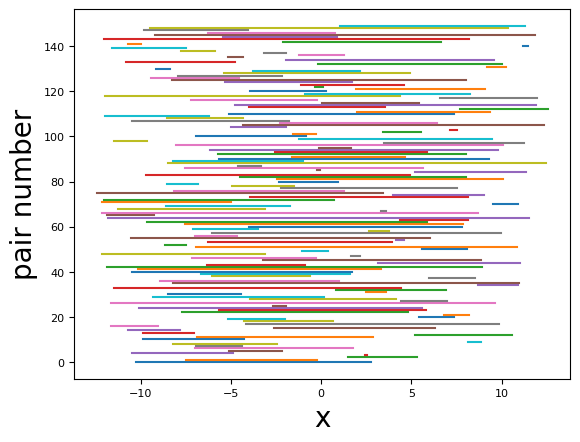

In [23]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Generate func vals

# Linear

In [24]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = np.sin(X[component_ids==0])
Y[(component_ids==1)] = np.sin(X[component_ids==1])+3
Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

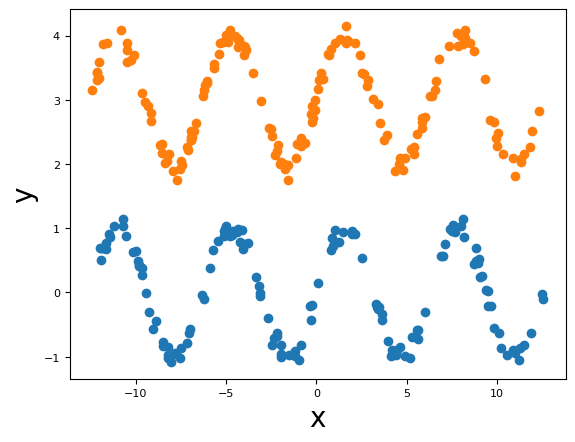

In [25]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
plt.xlabel("x")
plt.ylabel("y")
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=8)    # fontsize of the tick labels
plt.rc('ytick', labelsize=8)    # fontsize of the tick labels
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

Text(0.5, 0, 'x')

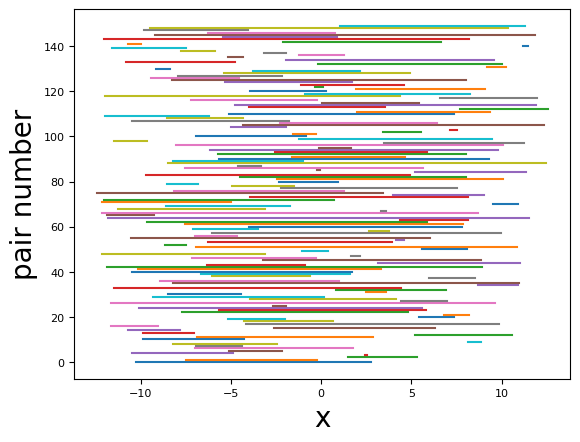

In [26]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Nonlinear

In [27]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = np.sin(X[component_ids==0])
Y[(component_ids==1)] = np.cos(X[component_ids==1]) #np.sin(X[component_ids==1])+3
Y = Y + np.random.normal(0, noise_sd, Y.shape)

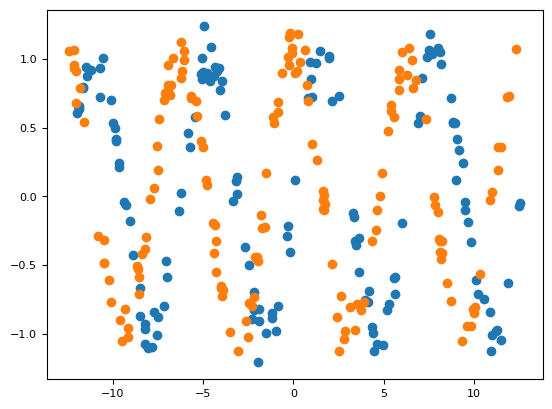

In [28]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

# EM

In [29]:
def lstsq_nesterov(X, Y, alpha0, maxiter=2000):
    Y = Y.flatten()
    ss = 1/np.linalg.norm(X, ord='fro')**2
    alpha = alpha0
    z = alpha0
    gamma = 1
    XtX = X.T@X
    XtY = X.T@Y
    for i in range(maxiter):
        alpha_old = alpha
        alpha = z + ss*(XtY-XtX@z)
        gamma = (np.sqrt(4*gamma**2 + gamma**4) - gamma**2)*0.5
        beta = gamma*(1-1/gamma)
        z = alpha + beta*(alpha - alpha_old)
    return alpha  

In [30]:
kern_width = 0.8

K = gauss_kernal_mat(X,X,sigma=kern_width)
# K = periodic_kernel_mat(X, X, sigma=1.0, period=np.pi, lengthscale=1.0)

# transformer = KernelCentere
#r().fit(K)
# K = transformer.transform(K)


### periodic kernel???
# Assuming x1 and x2 are input tensors
# periodic_kernel = gpytorch.kernels.PeriodicKernel()
# # Optional: To add a scaling parameter (outputscale)
# scaled_periodic_kernel = gpytorch.kernels.ScaleKernel(periodic_kernel)
# covar = scaled_periodic_kernel(x1, x2)

w, A = scipy.sparse.linalg.eigs(K, k=M)
print(np.shape(A))
w = np.real(w)
A = np.real(A)
w = w/np.sum(w)
maxiter = 30

R = np.zeros((n,M))

for i in range(maxiter):
    print(i)
    # E-step
    Delta = (Y - K@A)**2 #square loss for each observation for each component
    #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
    Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
    R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
    
    # M-step
    w = np.sum(R,axis=0) / n
    for j in range(M):
        Rm = np.repeat(R[:,j]**0.5,2,axis=0)
        print(np.shape(Rm))
        A[:,j] = lstsq_nesterov((K.T*Rm).T, (Y.T*Rm).T, A[:,j])
        #A[:,j] = np.linalg.lstsq((K.T*Rm).T, (Y.T*Rm).T, rcond=None)[0].flatten()
        print("final: ", np.linalg.norm((Y.T*Rm).T.flatten() - (K.T*Rm).T@A[:,j]))


(300, 2)
0
(300,)
final:  6.182690901807981
(300,)
final:  5.864148673851169
1
(300,)
final:  6.174156661159727
(300,)
final:  5.856054131077157
2
(300,)
final:  6.168999442813856
(300,)
final:  5.851162620955669
3
(300,)
final:  6.165026801046258
(300,)
final:  5.847394656112644
4
(300,)
final:  6.161763386023836
(300,)
final:  5.84429937750662
5
(300,)
final:  6.158993481372765
(300,)
final:  5.841672182819993
6
(300,)
final:  6.1565863881430065
(300,)
final:  5.839389106923866
7
(300,)
final:  6.154454500371918
(300,)
final:  5.837367057456382
8
(300,)
final:  6.15253666308356
(300,)
final:  5.835548030244802
9
(300,)
final:  6.150789161055201
(300,)
final:  5.833890562345323
10
(300,)
final:  6.1491801570988684
(300,)
final:  5.832364456873354
11
(300,)
final:  6.147686069082386
(300,)
final:  5.830947346686284
12
(300,)
final:  6.1462891421430355
(300,)
final:  5.829622391680614
13
(300,)
final:  6.14497579021596
(300,)
final:  5.8283767057675115
14
(300,)
final:  6.14373544580143

In [31]:
Rprime = copy(R)
Rprime[R<0.01] = 0
Rprime[R>0.99] = 1
print(Rprime)

[[0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235 0.4735765]
 [0.5264235

# Check out the results

In [32]:
Y_hat = np.zeros((2*n,M))
for j in range(M):
        #Rm = np.repeat(R[:,j]**0.5,2,axis=0)
        #Y_hat[:,j] = (K.T*Rm).T@A[:,j]
        Y_hat[:,j] = K@A[:,j]

Prop Correct Mixture Assignment = 0.5266666666666666


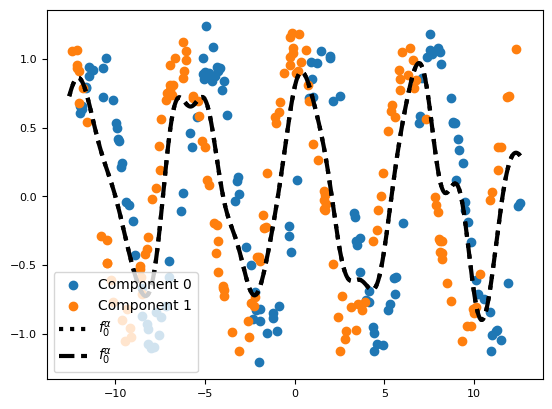

In [33]:
plt.scatter(X[component_ids==0],Y[component_ids==0], label="Component 0")
plt.scatter(X[component_ids==1],Y[component_ids==1], label="Component 1")

xx = np.reshape(np.linspace(-4*np.pi,4*np.pi,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=kern_width)
# Ktest = periodic_kernel_mat(xx, X, sigma=1.0, period=np.pi, lengthscale=1.0)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")

Rdouble = np.repeat(R,2,axis=0)
correct_assignments = max(sum(component_ids==np.argmax(Rdouble,axis=1) ), 
                          sum((1-component_ids)==np.argmax(Rdouble,axis=1)) 
                         ) / (2*n)
print(f"Prop Correct Mixture Assignment = {correct_assignments}")

plt.rcParams.update({'font.size': 10})
plt.legend()

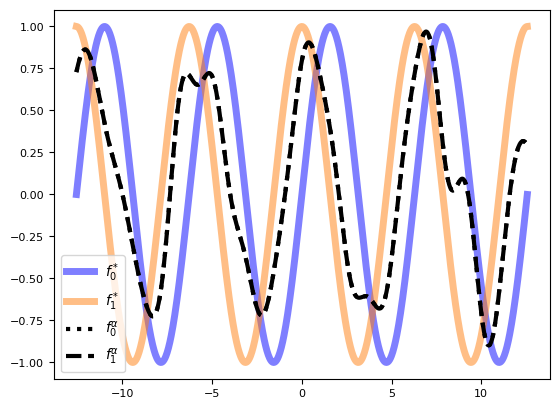

In [34]:
plt.plot(xx, np.sin(xx), 'b', linewidth=5, label="$f_0^*$", alpha=0.5)
plt.plot(xx, np.cos(xx), 'tab:orange', linewidth=5, label="$f_1^*$", alpha=0.5) #np.sin(xx+np.pi) 
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_1^\alpha$")
plt.rcParams.update({'font.size': 10})
plt.legend()


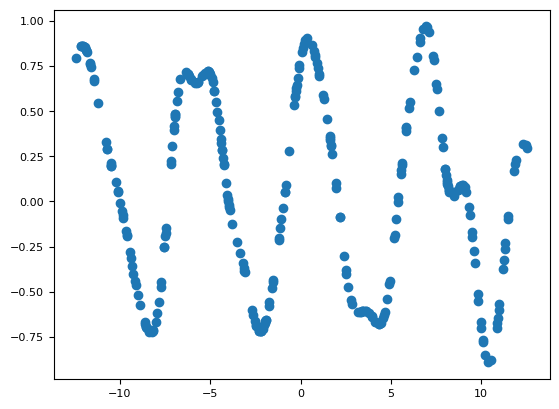

In [35]:
Rdouble = np.repeat(R,2,axis=0)
plt.scatter(X[np.argmax(Rdouble,axis=1)==0],Y_hat[np.argmax(Rdouble,axis=1)==0,0])
plt.scatter(X[np.argmax(Rdouble,axis=1)==1],Y_hat[np.argmax(Rdouble,axis=1)==1,1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

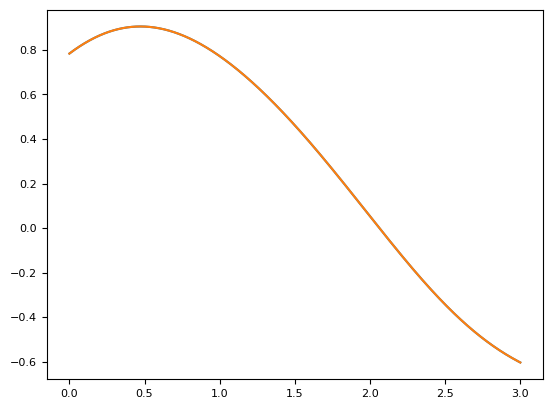

In [36]:
xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=0.95)
# Ktest = periodic_kernel_mat(xx, X, sigma=1.0, period=np.pi, lengthscale=1.0)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0])
plt.plot(xx, Yhat[:,1])